In [ ]:
######################
# Load the fUSI data #
######################

import nibabel as nib
import numpy as np
from pathlib import Path
import tqdm
import matplotlib.pyplot as plt

# Define the base path where your NIfTI files are stored
base_path = Path('/Users/clairenastaskin/data/2025-05-07/sub-Forest001_ses-20250507_task-face_run-002')  
pwd_file_name = 'sub-Forest001_ses-20250507_task-face_run-002_pwd.nii.gz'

pwd_path = base_path / pwd_file_name
# Load fUSI nifti file and get data into a numpy array
nifti_img = nib.load(pwd_path)
fusi_data = nifti_img.get_fdata()
fusi_data = np.nan_to_num(fusi_data, nan=0) # no nan
print(fusi_data.shape)

(152, 72, 139, 132)


Text(0, 0.5, 'Average Intensity')

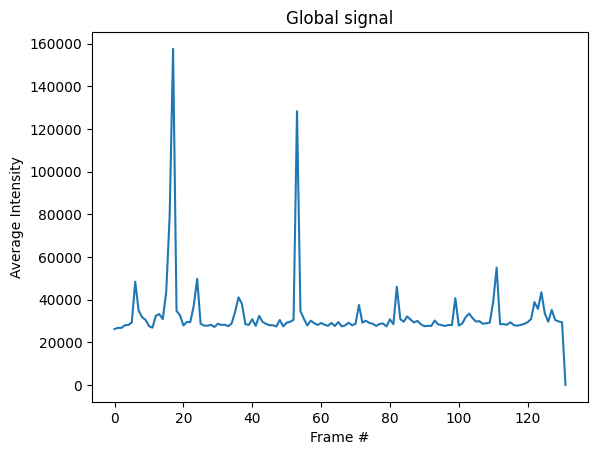

In [2]:
#######################################################################################
#     Display and save power Doppler movie, and display overall intensity over time   #
#######################################################################################

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.pyplot as plt

movie_path = base_path / "Doppler_movie.mp4"

if not movie_path.exists():
    # Convert to dB scale
    fusi_data_dB = 10*np.log10(fusi_data)
    nnz_idx = fusi_data > np.finfo(fusi_data.dtype).eps
    vmax = np.percentile(fusi_data_dB[nnz_idx], 90)
    vmin = np.percentile(fusi_data_dB[nnz_idx], 10)
    print(vmin)
    print('dynamic range: ', vmax-vmin)
    
    # Save fusi_data_dB as a NIfTI file
    output_filename = pwd_file_name.replace('.nii.gz', '_db.nii.gz')
    output_path = base_path / output_filename
    nifti_img_db = nib.Nifti1Image(fusi_data_dB, nifti_img.affine, nifti_img.header)
    nib.save(nifti_img_db, output_path)

    # Create animation
    fig, ax = plt.subplots()
    cax = ax.imshow(fusi_data_dB[:, fusi_data_dB.shape[1]//2, :, 0].T, cmap="inferno", extent=[0, 60, 86, 25], vmax=vmax+7, vmin=vmin)
    plt.colorbar(cax, ax=ax, label='Intensity (dB)')
    ax.set_title("0")

    ax.set_xlabel("Y (mm)")
    ax.set_ylabel("X (mm)")

    def update(frame):
        cax.set_data(fusi_data_dB[:, fusi_data_dB.shape[1]//2,:, frame].T)
        ax.set_title(f"Frame # {frame}")

    frames_to_plot = range(0, fusi_data_dB.shape[3], 1)
    ani = FuncAnimation(fig, update, frames=frames_to_plot, interval=100)

    # Save the animation
    ani.save(movie_path, writer="ffmpeg")
    plt.close(fig)

# Display the saved movie
from IPython.display import Video
from IPython.display import display
display(Video(str(movie_path), embed=True, width=800, html_attributes="controls autoplay"))


global_signal = np.mean(fusi_data, axis=(0, 1, 2))
fig,ax = plt.subplots()
ax.plot(global_signal)
ax.set_title("Global signal")
ax.set_xlabel("Frame #")
ax.set_ylabel("Average Intensity")

Text(0, 0.5, 'Derivative of global signal')

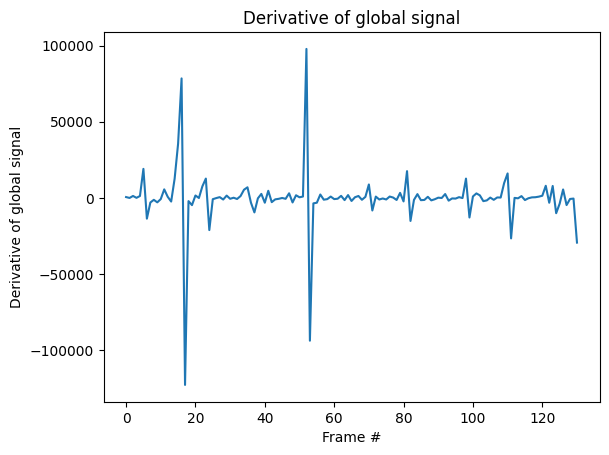

In [3]:
deriv_global_signal = np.diff(global_signal)
fig,ax = plt.subplots()
ax.plot(deriv_global_signal)
ax.set_title("Derivative of global signal")
ax.set_xlabel("Frame #")
ax.set_ylabel("Derivative of global signal")
# ax.set_ylim(-1000, 1000)
# ax.set_xlim(0, 40)



In [4]:
##############################################
# Extract Sequoia and Psychotria time_stamps #
##############################################

import pandas as pd
from datetime import datetime
from datetime import datetime, timedelta

# Extract psychotria time events
task_path = list(base_path.glob('*events.tsv'))[0]
task_tsv_file = pd.read_csv(task_path, sep='\t')
start_time_psychotria = datetime.fromisoformat(task_tsv_file['timestamp'].iloc[0])
time_stamps_psychotria_before_adjustement = [(t - start_time_psychotria).total_seconds() for t in pd.to_datetime(task_tsv_file['timestamp'], format='ISO8601')]

# Extract sequoia time events
time_sequoia_path = base_path / 'logs.csv'
time_sequoia = pd.read_csv(time_sequoia_path, sep=',')
time_stamps_sequoia_before_adjustement = time_sequoia['PERF_COUNTER']
time_utc = time_sequoia['TIME_UTC']
diff_time_between_sequoia_and_forest = np.zeros(len(time_sequoia))


# Check who, from psychotria and sequoia, started first
diff_time_between_sequoia_and_forest = [(t - start_time_psychotria).total_seconds() for t in pd.to_datetime(time_utc, format='ISO8601')]

print('Psychotria task start time: ')
print(start_time_psychotria)
print(' ')
print('Sequoia task start time: ')
print(pd.to_datetime(time_utc[0], format='ISO8601'))

if diff_time_between_sequoia_and_forest[0] < 0:
    print(' ')
    print('Psychotria task started after start of fUSI recording')
    time_stamps_sequoia = time_stamps_sequoia_before_adjustement - time_stamps_sequoia_before_adjustement[0]
    time_stamps_psychotria = [t - diff_time_between_sequoia_and_forest[0] for t in time_stamps_psychotria_before_adjustement]
else:
    print(' ')
    print('Psychotria task started before start of fUSI recording')
    time_stamps_sequoia = time_stamps_sequoia_before_adjustement - time_stamps_sequoia_before_adjustement[0] + diff_time_between_sequoia_and_forest[0]
    time_stamps_psychotria = [t for t in time_stamps_psychotria_before_adjustement]

# Create frame_time array from sequoia timestamps
frame_times = np.array(time_stamps_sequoia)
print(' ')
print('Sequoia frame times')
print(frame_times)


Psychotria task start time: 
2025-05-07 19:24:02.848000+00:00
 
Sequoia task start time: 
2025-05-07 19:23:58.697398+00:00
 
Psychotria task started after start of fUSI recording
 
Sequoia frame times
[  0.           2.81223856   5.62494355   8.43736714  11.24973884
  14.06225031  16.87468175  19.68714179  22.49979216  25.31222589
  28.12467407  30.9371274   33.74972561  36.56223794  39.37479974
  42.18708937  44.99955378  47.81211907  50.62467221  53.43723418
  56.24968772  59.06219257  61.8747885   64.68713455  67.49964186
  70.31213922  73.12476102  75.93713812  78.74965535  81.56220652
  84.37464278  87.18725627  89.99980944  92.81226761  95.62491799
  98.43721841 101.24975195 104.06221449 106.87474884 109.68729967
 112.49999622 115.31262535 118.12474744 120.93740149 123.74997815
 126.56221037 129.37471535 132.1871942  134.99988422 137.81243575
 140.62492089 143.43724728 146.24989883 149.06244226 151.87514603
 154.68731813 157.4998834  160.31250111 163.12524552 165.93762414
 168.75

In [5]:
######################
# Create task_events #
######################

task_events = pd.DataFrame(columns=['trial_type', 'onset','duration'])
k = 0
for n in range(len(task_tsv_file)):
    if task_tsv_file['start'].iloc[n]:
        task_events.loc[k] = {
            'trial_type': task_tsv_file['stimulus'].iloc[n],
            'onset': time_stamps_psychotria[n]
        }
    
        # Find next stop index after current start index n
        ind = n + 1
        while ind < len(task_tsv_file) and not task_tsv_file['stop'].iloc[ind]:
            ind += 1
        
        # Calculate duration if stop found
        if ind < len(task_tsv_file):
            task_events.loc[k, 'duration'] = time_stamps_psychotria[ind] - time_stamps_psychotria[n]
        k += 1
        
# Replace NaN duration values with 0
task_events['duration'] = task_events['duration'].fillna(0)
task_events

,trial_type,onset,duration
0,M1_Neu.jpg,4.150602,9.001
1,F3_Fear.jpg,26.509602,9.001
2,M1_Sad.jpg,49.357602,9.001
3,F3_Hap.jpg,70.500602,9.001
4,M6_Hap.jpg,91.994602,9.001
5,blue_rect5.jpg,114.420602,9.001
6,F1_Hap.jpg,136.121602,9.001
7,F1_Fear.jpg,158.568602,9.001
8,M4_Sad.jpg,180.337602,9.001
9,F2_Fear.jpg,201.523602,9.001


In [6]:
########################################
#   Replace the emotion/face mappings  #
########################################

task_events.trial_type = task_events.trial_type.replace({
    r'.*_Hap\.jpg': 'face_happy',
    r'.*_Neu\.jpg': 'face_neutral', 
    r'.*_Fear\.jpg': 'face_fear',
    r'blue_rect.*\.jpg': 'blue_square',
    r'.*_Sad\.jpg': 'face_sad',
}, regex=True)
task_events



,trial_type,onset,duration
0,face_neutral,4.150602,9.001
1,face_fear,26.509602,9.001
2,face_sad,49.357602,9.001
3,face_happy,70.500602,9.001
4,face_happy,91.994602,9.001
5,blue_square,114.420602,9.001
6,face_happy,136.121602,9.001
7,face_fear,158.568602,9.001
8,face_sad,180.337602,9.001
9,face_fear,201.523602,9.001


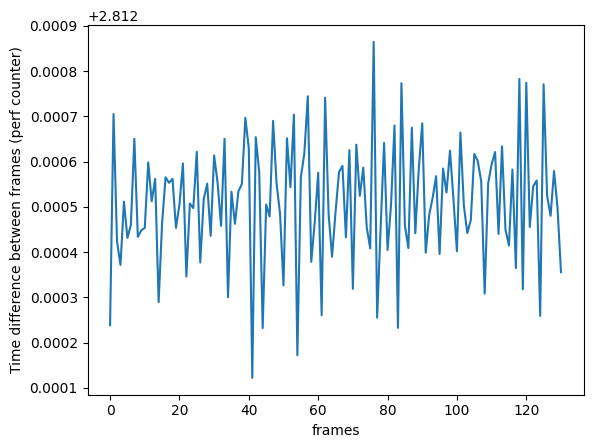

In [7]:
###############################################
# Plot time difference between doppler frames #
###############################################
import numpy as np
import os

diff_perf = np.diff(time_stamps_sequoia)
fig, ax = plt.subplots()
ax.plot(diff_perf)
ax.set_ylabel('Time difference between frames (perf counter)')
ax.set_xlabel('frames')
t_r = np.median(diff_perf)
t_r

# Save t_r value to base_path
np.save(os.path.join(base_path, 't_r.npy'), t_r)


Indexes to mask =  [16 17 53]
(129,)


/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_5404/2723265146.py:22: DeprecationWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  average_over_time_detrended = clean(


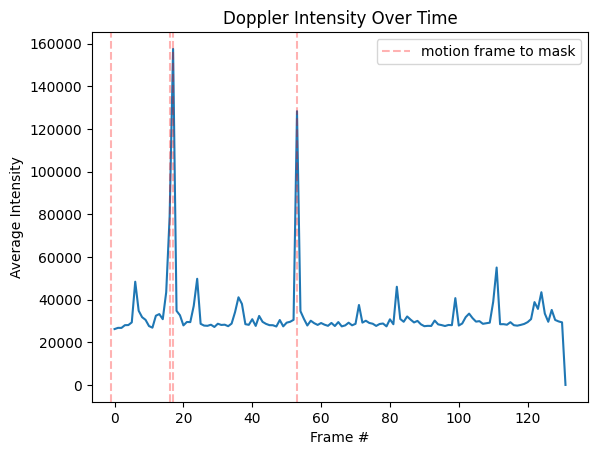

In [8]:
##########################################################################################
#     Display Doppler intensity time course and create a sample_masks for motion frames  #
##########################################################################################

from nilearn.signal import clean

fusi_data = fusi_data[:, :, :, :]
average_over_time = np.mean(fusi_data, axis=(0, 1, 2))
fig,ax = plt.subplots()
ax.plot(average_over_time)
ax.set_title("Doppler Intensity Over Time")
ax.set_xlabel("Frame #")
ax.set_ylabel("Average Intensity")


###################################################
# Detrend the time course to remove linear trends #
###################################################

# Reshape to 2D array since clean expects samples x features
average_over_time_2d = average_over_time.reshape(-1, 1)
average_over_time_detrended = clean(
    average_over_time_2d,
    detrend=True,
    t_r=t_r,
)
# Convert back to 1D array
average_over_time_detrended = average_over_time_detrended.ravel()

#######################################################################################################################
# Based on detrended signal, find motion frames (here defined as frames with values higher than median + 5 times std) #
#######################################################################################################################
median_detrended_signal=np.median(average_over_time_detrended)
perc_50 = np.percentile(average_over_time_detrended,50)
perc_50_signal = average_over_time_detrended[average_over_time_detrended < perc_50]
std_perc_50 = np.std(perc_50_signal)

# Find frames with values > median + 5*std of lower 50% of signal
index_to_mask = np.where(average_over_time_detrended > (median_detrended_signal + 10*std_perc_50))[0]
# Add vertical lines for motion frames
for frame in index_to_mask:
    ax.axvline(x=frame, color='r', linestyle='--', alpha=0.3)
ax.axvline(x=-1, color='r', linestyle='--', alpha=0.3, label='motion frame to mask')
ax.legend()
print('Indexes to mask = ', index_to_mask)

#############################
#     Create sample_masks  #
############################
sample_masks = np.zeros(fusi_data.shape[3] - len(index_to_mask), dtype=int)
t = 0
for i in range(fusi_data.shape[3]):
    if i not in index_to_mask:
        sample_masks[t] = i
        t += 1

print(sample_masks.shape)

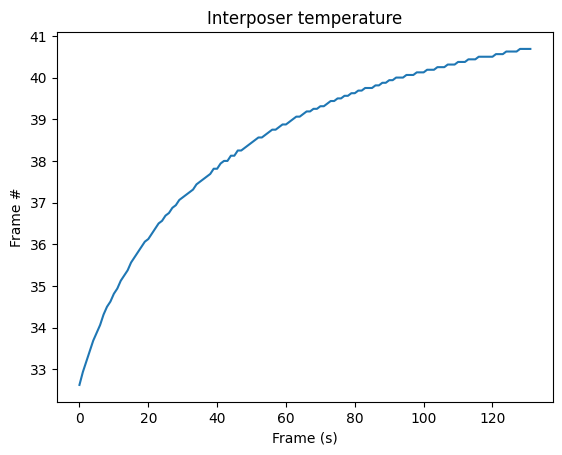

In [9]:
# ################################
# # Plot temperature time course #    
# ################################

temp_log_path = base_path / 'logs.csv'
temp_log = pd.read_csv(temp_log_path, sep=',') 
temp_log = temp_log['INTERPOSER_TEMP']

fig,ax = plt.subplots()
ax.plot(temp_log)
ax.set_title('Interposer temperature')
ax.set_xlabel('Frame (s)')
ax.set_ylabel('Frame #')
plt.show()


In [10]:
#########################################
#######  Rigid transformation  #########
########################################
import fusi_utils_BIDS as utils

transformation_file = base_path / "rigid_transformations.nii.gz"

if not transformation_file.exists():
    fusi_data_rigid_reg, rigid_transformations = utils.register_3d_image_stack(fusi_data)
    
    # Save rigid transformations to file
    # Create an affine transformation matrix with voxel sizes of 0.15mm 
    # (lambda at 4 MHz ~ 0.30mm. We reconstruct at lambda/2) in x,y,z,t dimensions)
    affine = np.diag([0.17, 0.17, 0.17, 1])
    nib.save(nib.Nifti1Image(rigid_transformations, affine), transformation_file)
    nib.save(nib.Nifti1Image(fusi_data_rigid_reg, affine), base_path / "fusi_data_rigid_reg.nii.gz")
else:
    # Load rigid transformations from file
    rigid_transformations = nib.load(transformation_file).get_fdata()
    fusi_data_rigid_reg = nib.load(base_path / "fusi_data_rigid_reg.nii.gz").get_fdata()

# Plot rigid_transformations
fig, axes = plt.subplots(nrows=2, ncols=1,layout="constrained")
ax_tran=axes[0]
ax_tran.plot(rigid_transformations[0, :], label="Translation X")
ax_tran.plot(rigid_transformations[1, :], label="Translation Y")
ax_tran.plot(rigid_transformations[2, :], label="Translation Z")
ax_tran.set_xlabel("Frame Index")
ax_tran.set_ylabel("translation (pixels)")
ax_tran.legend()
ax_tran.grid(True)
ax_tran.legend()

ax_rot=axes[1]
ax_rot.plot(rigid_transformations[3, :] * 180 / np.pi, label="Rotation Angle X")
ax_rot.plot(rigid_transformations[4, :] * 180 / np.pi, label="Rotation Angle Y")
ax_rot.plot(rigid_transformations[5, :] * 180 / np.pi, label="Rotation Angle Z")
ax_rot.set_xlabel("Frame Index")
ax_rot.set_ylabel("rotation (degrees)")
ax_rot.legend()
ax_rot.grid(True)
ax_rot.legend()

# Save figure
fig.savefig(base_path / "registration.png")

/Users/clairenastaskin/Documents/Anise/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


RuntimeError: Exception thrown in SimpleITK CenteredTransformInitializer: /Users/ec2-user/actions-runner/_work/SimpleITK/SimpleITK/bld/ITK-prefix/include/ITK-5.4/itkImageMomentsCalculator.hxx:124:
ITK ERROR: ImageMomentsCalculator(0x431093840): Compute(): Total Mass of the image was zero. Aborting here to prevent division by zero later on.

In [11]:
######################################################################
#     Display and save power Doppler movie after rigid registration  #
######################################################################

movie_file = base_path / "Doppler_movie_after_rigid_registration.mp4"

if not movie_file.exists():
    fusi_data_rigid_reg_dB = 10*np.log10(fusi_data_rigid_reg)
    nnz_idx = fusi_data_rigid_reg > np.finfo(fusi_data_rigid_reg.dtype).eps
    vmax = np.percentile(fusi_data_rigid_reg_dB[nnz_idx], 98)
    vmin = np.percentile(fusi_data_rigid_reg_dB[nnz_idx], 2)
    print(vmin)
    print('dynamic range: ', vmax-vmin)

    # Create figure and initial plot
    fig, ax = plt.subplots()
    cax = ax.imshow(
        fusi_data_rigid_reg_dB[:, int(fusi_data_rigid_reg_dB.shape[1] / 2), :, 0].T,
        cmap="inferno",
        extent=[0, 60, 85, 25],
    )
    ax.set_title("0")

    # Set axis labels
    ax.set_xlabel("Y (mm)")
    ax.set_ylabel("X (mm)")
    plt.colorbar(cax, ax=ax, label='Intensity (dB)')

    def update(frame):
        cax.set_data(
            fusi_data_rigid_reg_dB[:, int(fusi_data_rigid_reg_dB.shape[1] / 2), :, frame].T
        )
        ax.set_title(f"Frame # {frame}")
        return (cax,)

    # Create a list of frames to plot every other frame
    frames_to_plot = range(0, fusi_data_rigid_reg.shape[3], 2)
    ani = FuncAnimation(fig, update, frames=frames_to_plot, interval=100, blit=True)

    # Save the animation as an MP4 file
    ani.save(movie_file, writer="ffmpeg")
    plt.close()
    display(HTML(ani.to_jshtml()))

else:
    # Display the saved movie
    from IPython.display import Video
    from IPython.display import display
    display(Video(str(movie_file), embed=True, width=800, html_attributes="controls autoplay"))



In [12]:
################################
# Keep registration or not ? #
###############################

# Here, the rigid registration is not good, so we don't use it and it doesn't seem to be needed

# fusi_data = fusi_data_rigid_reg  # If we're happy about the registration
regressed_with_transformations = False

/Users/clairenastaskin/Documents/Anise/.venv/lib/python3.9/site-packages/nilearn/glm/first_level/design_matrix.py:416: UserWarning: The following conditions contain events with null duration:
- 'face_fear'

  matrix, names = _convolve_regressors(
/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_3556/1637315233.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


<Figure size 640x480 with 0 Axes>

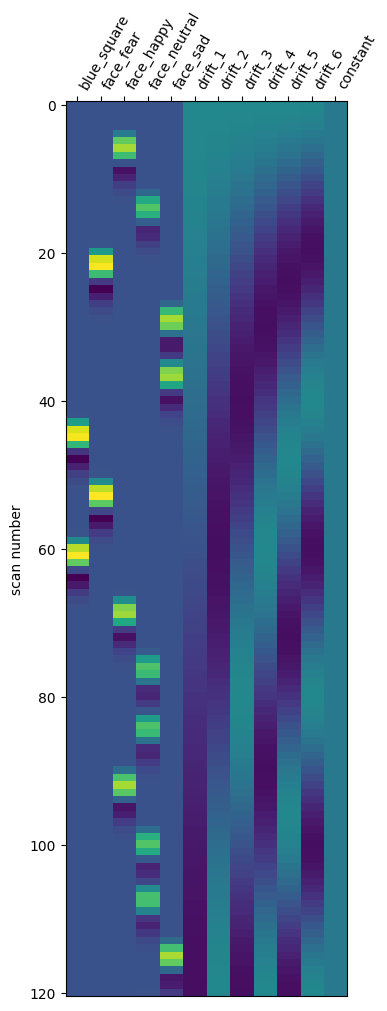

In [ ]:
#######################################
#     Create design matrix for GLM    #
#######################################
from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.plotting import plot_design_matrix
import os

event_time_offset = 0 #t_r # in seconds 
task_events["onset"] += event_time_offset

if regressed_with_transformations:
    events_df = make_first_level_design_matrix(
        frame_times,
        task_events,
        drift_model="cosine", 
        high_pass=0.01,
        add_regs=rigid_transformations.transpose(),
        add_reg_names=["tx", "ty", "tz", "rotx", "roty", "rotz"],
        hrf_model="glover",
    )
else:
    events_df = make_first_level_design_matrix(
        frame_times,
        task_events,
        drift_model="cosine",
        high_pass=0.01,
        hrf_model="glover",
    )


design_matrix = events_df
fig = plt.figure()
plot_design_matrix(design_matrix)
fig.show()

# Save design matrix as .npz file
np.savez(os.path.join(base_path, 'design_matrix.npz'), design_matrix=design_matrix.values, column_names=design_matrix.columns)

In [14]:

##########################################
## Create contrasts for localizer task ##
##########################################

def make_localizer_contrasts(design_matrix):
    contrast_matrix = np.eye(design_matrix.shape[1])
    contrasts = {
        column: contrast_matrix[i]
        for i, column in enumerate(design_matrix.columns)
    }
    # contrasts["right_wrist_minus_left_wrist"] = (
    #     contrasts["right_wrist_motion.mp4"]
    #     - contrasts["left_wrist_motion.mp4"])
    return contrasts
    
contrasts = make_localizer_contrasts(design_matrix)
print("Contrasts:")
for name in [k for k in contrasts.keys() if 'drift' not in k]:
    print(f"- {name}")

Contrasts:
- blue_square
- face_fear
- face_happy
- face_neutral
- face_sad
- constant


In [ ]:
###########################################
# Temporal smoothing and convert to NIfTI #
###########################################
import fusi_utils_BIDS as utils

from nilearn.signal import butterworth
window_size = 3  # Number of time points for smoothing
pd = utils.boxcar_smooth(fusi_data, window_size)

# Create an affine transformation matrix with voxel sizes of 0.15mm 
# (lambda at 4 MHz ~ 0.34mm. We reconstruct at lambda/2) in x,y,z,t dimensions)
# This defines how the image data maps to real-world coordinates
affine = np.diag([0.17, 0.17, 0.17, 1])

# Create a NIfTI image object from our processed data (pd) and the affine matrix
fusi_img = nib.Nifti1Image(pd, affine)
fusi_img.to_filename(base_path / "fUSi_data_after_processing.nii.gz")
fusi_img.shape

(152, 72, 139, 121)

In [ ]:
###########
# Fit GLM #
##########
from nilearn.glm.first_level import FirstLevelModel

smoothing_fwhm = (0.5) # 0 spatial smoothing in mm to apply to the data before computing GLM

# Filter sample_masks to only include values up to fusi_img.shape[3]
sample_masks = sample_masks[sample_masks <= fusi_img.shape[3]-1]

# Initialize and fit the GLM model with specified parameters
print("Fitting a GLM")
fusi_glm = FirstLevelModel(
    t_r=t_r,
    minimize_memory=False,
    mask_img=False,
    smoothing_fwhm=smoothing_fwhm,
    standardize=True,
)
fusi_glm = fusi_glm.fit(fusi_img, design_matrices=design_matrix, sample_masks=[sample_masks])

Fitting a GLM


/Users/clairenastaskin/Documents/Anise/.venv/lib/python3.9/site-packages/nilearn/glm/first_level/first_level.py:585: UserWarning: Mean values of 0 observed. The data have probably been centered.Scaling might not work as expected
  Y, _ = mean_scaling(Y, self.signal_scaling)


Display GLM map (maps upside down)

Computing contrasts
	contrast id: blue_square


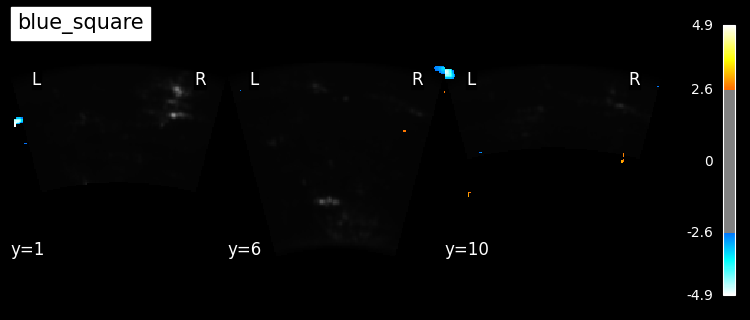

	contrast id: face_fear


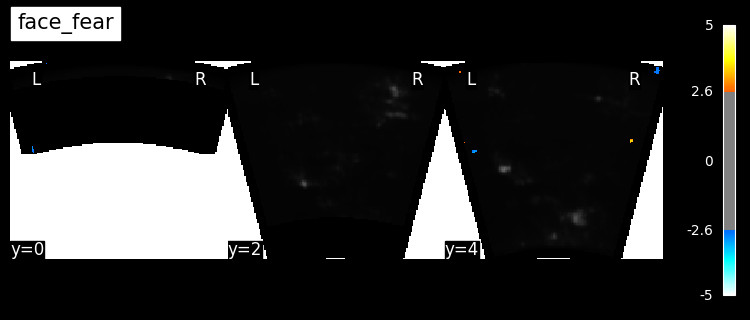

	contrast id: face_happy


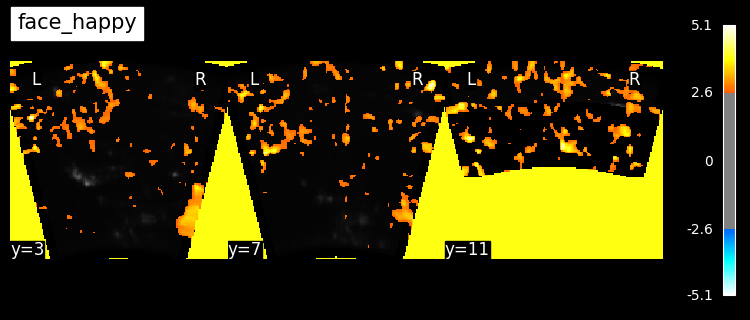

	contrast id: face_neutral


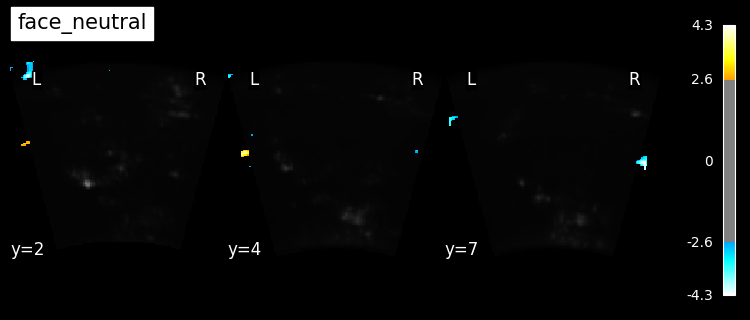

	contrast id: face_sad


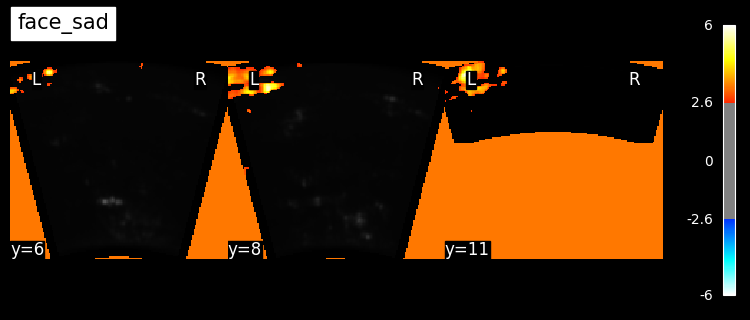

In [ ]:
from nilearn import plotting
from nilearn.image import concat_imgs, mean_img, resample_img
import scipy.io
import os
import nibabel as nib
import numpy as np

print("Computing contrasts")
affine_zmap = np.diag([0.17, 0.17, 0.17, 1])
mean_image = nib.Nifti1Image(
    np.mean(fusi_img.get_fdata(), axis=-1), fusi_img.affine
)
os.makedirs(base_path, exist_ok=True)  # Create the directory if it doesn't exist


########################
# Iterate on contrasts #
########################

# Uncomment the line below to see all the contrasts
# for contrast_id, contrast_val in contrasts.items(): 

# Uncomment line below to see only the contrasts of the tasks and not the translations, rotations, etc ...
for contrast_id, contrast_val in {k: v for k, v in contrasts.items() if k not in ['tx', 'ty', 'tz', 'rotx', 'roty', 'rotz', 'constant'] and not k.startswith('drift')}.items():    
    print(f"\tcontrast id: {contrast_id}")
    # compute the contrasts
    z_map = fusi_glm.compute_contrast(contrast_val, output_type="stat")

    # Get the data from z_map and create new NIfTI image
    z_map_data = z_map.get_fdata()
    nii_zmap = nib.Nifti1Image(z_map_data, affine_zmap)
    # Save the NIfTI zmap to a compressed .nii.gz file in the base_path
    output_path = os.path.join(base_path, f"{contrast_id}_z_map.nii.gz")
    nib.save(nii_zmap, output_path)

    # plot the contrasts as soon as they're generated
    # the display is overlaid on the mean fusi image
    # a threshold of 2.58 is used (corresponding to p < 0.01)
    plotting.plot_stat_map(
        z_map,
        bg_img=mean_image,
        threshold=2.58,
        cut_coords=3,
        display_mode="y",
        black_bg=True,
        title=contrast_id
    )
    plotting.show()

/Users/clairenastaskin/Documents/Anise/Experiments/fusi_utils_BIDS.py:1112: UserWarning: Attention: At least one of the (sub)peaks falls outside of the cluster body. Identifying the nearest in-cluster voxel.
  table = get_clusters_table(z_map, stat_threshold=threshold, cluster_threshold=10)


  Cluster ID      X     Y      Z  Peak Stat Cluster Size (mm3)
0          1   2.38  3.23  16.66   4.785577               2008
1         1a  24.14  7.14  20.57   4.717036                   


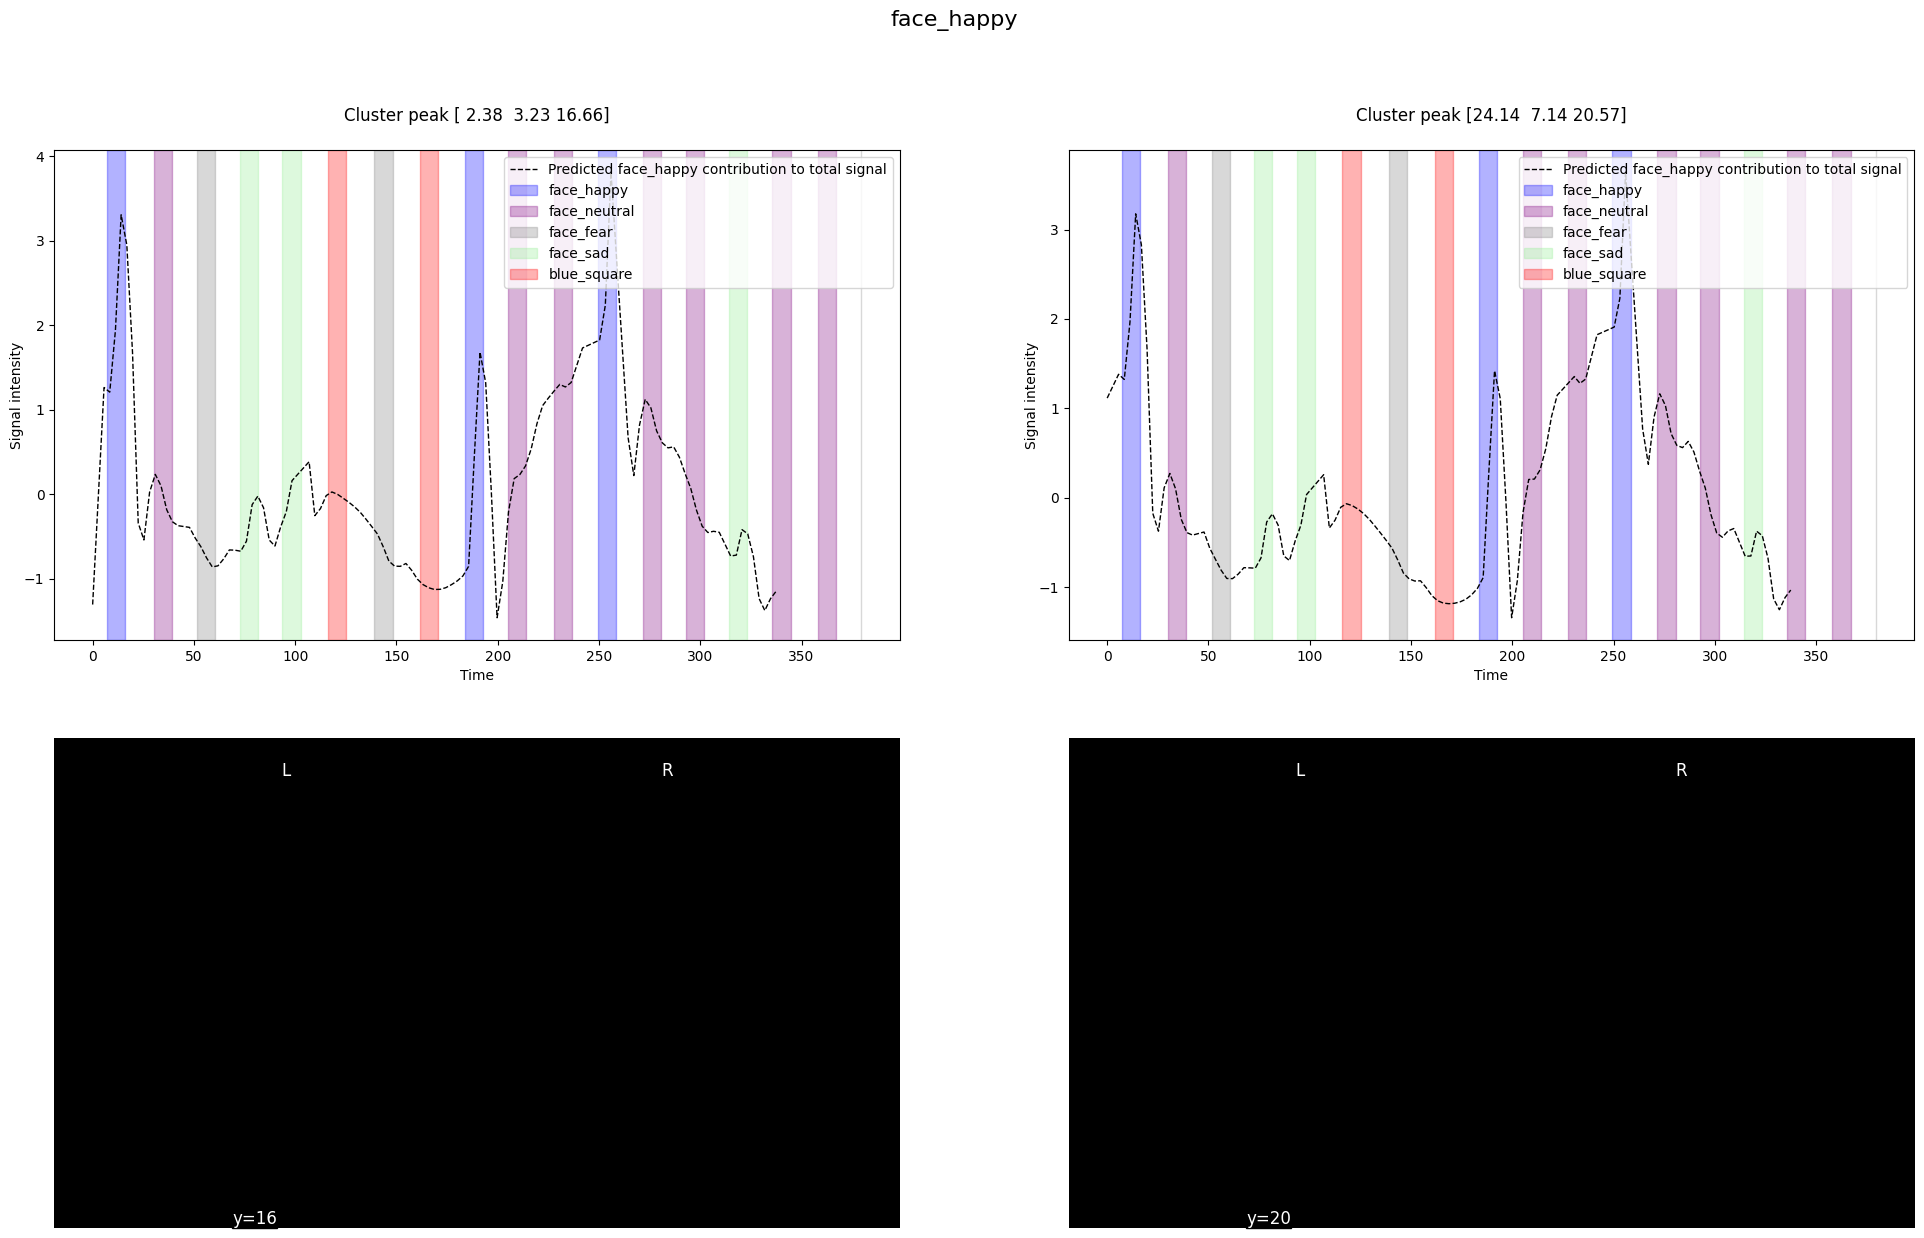

In [ ]:
#######################################################################################
#  Extract time series of clusters with z-scores > 2.58 and display their time courses #
#######################################################################################
import pandas as pd
# Create probe events DataFrame with time_stamp column
probe_events = pd.DataFrame(columns=['time_stamp'])
probe_events['time_stamp'] = frame_times


contrast = "face_happy"
threshold = 2.58
roi_radius = 5
[z_map, coords, real_timecourse, predicted_timecourse] = (
    utils.extract_time_course_from_main_clusters(
        contrast,
        threshold,
        sample_masks,
        fusi_img,
        fusi_glm,
        probe_events,
        t_r,
        roi_radius
    )
)
# utils.display_real_and_predicted_timecourses(contrast,real_timecourse, predicted_timecourse,task_events, coords, z_map, mean_image)
utils.display_predicted_timecourses(contrast, predicted_timecourse,task_events, coords, z_map, mean_image)

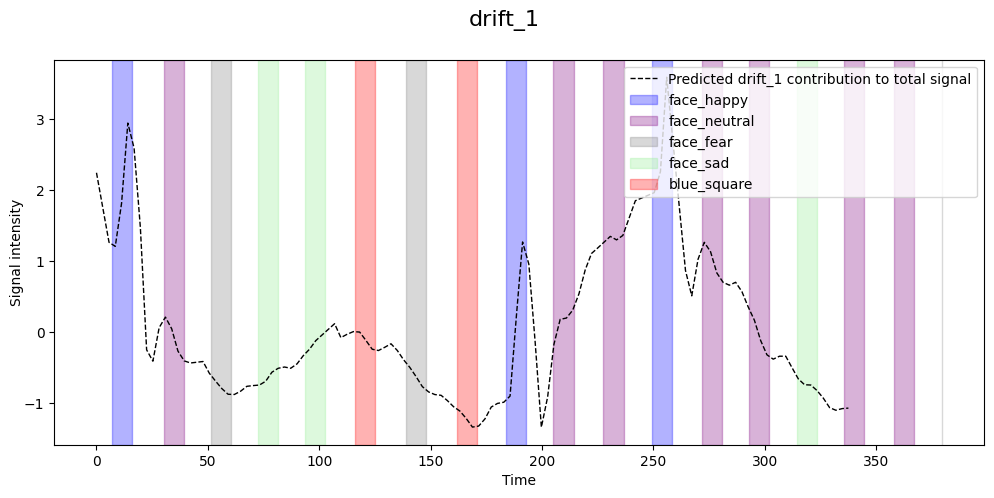

In [ ]:
#######################################
#  Extract time series of regressors #
######################################
contrast = "drift_1"

utils.display_regressor_temporal_component(
    contrast,
    fusi_glm=fusi_glm,
    probe_events=probe_events,
    t_r=t_r,
    sample_masks=sample_masks,
    task_events=task_events,
)
